Load the train and test datasets

In [102]:
import sys
sys.path.append("..")

import pandas as pd
from src.preprocessing import preprocess_complaint, preprocess_complaint_2

train_df = pd.read_parquet("../data/processed/train_complaints.parquet")
test_df  = pd.read_parquet("../data/processed/test_complaints.parquet")

print(train_df.shape)
print(test_df.shape)

(798916, 4)
(199730, 4)


Define features and targets

In [103]:
X_train = train_df["clean_narrative"]
X_test  = test_df["clean_narrative"]

y_train_dept = train_df["Department"]
y_test_dept  = test_df["Department"]

y_train_priority = train_df["Priority"]
y_test_priority  = test_df["Priority"]

Department classification pipeline (NB)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

department_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", MultinomialNB())
])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x3079ae980>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Train Department Model

In [57]:
dept_pipeline.fit(X_train, y_train_dept)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocess', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...t 0x305054d60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pa

Priority classification pipeline (NB)

In [59]:
priority_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", MultinomialNB())
])

priority_pipeline.fit(X_train, y_train_priority)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x3079ae980>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Predictions (NB)

In [60]:
dept_preds = dept_pipeline.predict(X_test)
priority_preds = priority_pipeline.predict(X_test)

Model Evaluation - Departmental (NB)

In [66]:
from sklearn.metrics import accuracy_score, classification_report

print("Department Model Accuracy:")
print(accuracy_score(y_test_dept, dept_preds))

print("\nDepartment Classification Report:")
print(classification_report(y_test_dept, dept_preds))

Department Model Accuracy:
0.817378460922245

Department Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.67      0.87      0.76     13449
          Card services       0.60      0.79      0.68     16384
         Consumer loans       0.60      0.62      0.61      4279
       Credit reporting       0.93      0.86      0.90    115002
        Debt collection       0.70      0.74      0.72     26470
Money transfer services       0.91      0.51      0.65      6723
               Mortgage       0.75      0.94      0.83     10509
Payday / personal loans       0.74      0.18      0.29      2477
           Student loan       0.75      0.81      0.78      4437

               accuracy                           0.82    199730
              macro avg       0.74      0.70      0.69    199730
           weighted avg       0.83      0.82      0.82    199730



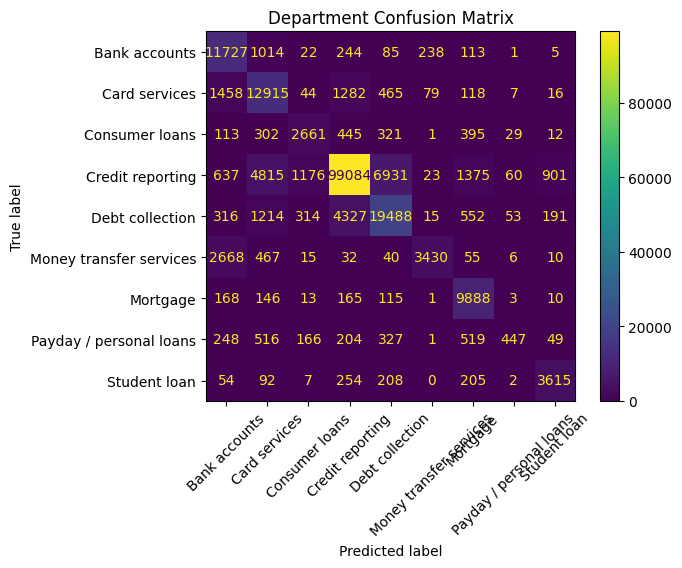

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_dept,
    dept_preds,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

Model Evaluation - Priority (NB)

In [69]:
print("Priority Model Accuracy:")
print(accuracy_score(y_test_priority, priority_preds))

print("\nPriority Classification Report:")
print(classification_report(y_test_priority, priority_preds))

Priority Model Accuracy:
0.9229359635507935

Priority Classification Report:
              precision    recall  f1-score   support

   Immediate       0.44      0.58      0.50      4481
     Regular       0.95      0.96      0.96    169513
    Same-day       0.82      0.75      0.78     25736

    accuracy                           0.92    199730
   macro avg       0.74      0.76      0.75    199730
weighted avg       0.92      0.92      0.92    199730



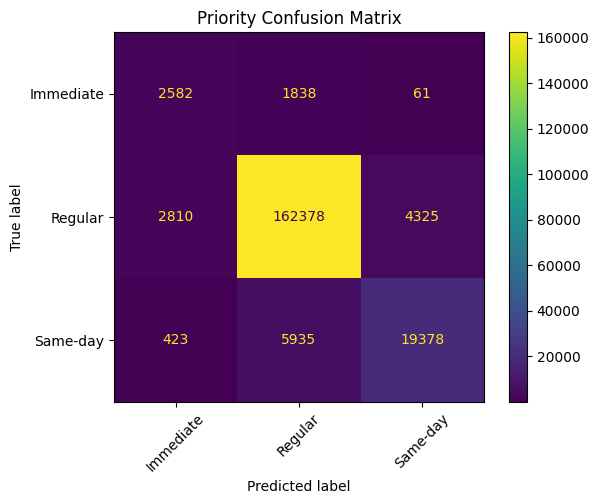

In [70]:
ConfusionMatrixDisplay.from_predictions(
    y_test_priority,
    priority_preds,
    xticks_rotation=45
)

plt.title("Priority Confusion Matrix")
plt.show()

Departmental classification pipeline (LR)

In [72]:
from sklearn.linear_model import LogisticRegression

dept_pipeline__2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
    ))
])

dept_pipeline__2.fit(X_train, y_train_dept)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x3079ae980>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Priority classification pipeline (LR)

In [85]:
priority_pipeline__2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint_2,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
    ))
])

priority_pipeline__2.fit(X_train, y_train_priority)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x3074168e0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [86]:
dept_preds_2 = dept_pipeline__2.predict(X_test)
priority_preds_2 = priority_pipeline__2.predict(X_test)

Model evaluation - Departmental (LR)

In [76]:
print("Department Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_dept, dept_preds_2))

print("\nClassification Report:")
print(classification_report(y_test_dept, dept_preds_2))

Department Model (Logistic Regression)

Accuracy:
0.8699694587693386

Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.80      0.84      0.82     13449
          Card services       0.80      0.77      0.78     16384
         Consumer loans       0.73      0.63      0.68      4279
       Credit reporting       0.91      0.94      0.93    115002
        Debt collection       0.80      0.73      0.76     26470
Money transfer services       0.82      0.75      0.79      6723
               Mortgage       0.90      0.90      0.90     10509
Payday / personal loans       0.65      0.47      0.55      2477
           Student loan       0.87      0.79      0.83      4437

               accuracy                           0.87    199730
              macro avg       0.81      0.76      0.78    199730
           weighted avg       0.87      0.87      0.87    199730



Model evaluation - Priority (LR)

In [87]:
print("Priority Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_priority, priority_preds_2))

print("\nClassification Report:")
print(classification_report(y_test_priority, priority_preds_2))

Priority Model (Logistic Regression)

Accuracy:
0.9464226706053172

Classification Report:
              precision    recall  f1-score   support

   Immediate       0.91      0.47      0.62      4481
     Regular       0.95      0.99      0.97    169513
    Same-day       0.92      0.74      0.82     25736

    accuracy                           0.95    199730
   macro avg       0.93      0.73      0.80    199730
weighted avg       0.95      0.95      0.94    199730



Logestic Regression with class balance

In [104]:
dept_pipeline__LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

dept_pipeline__LR.fit(X_train, y_train_dept)

priority_pipeline__LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint_2,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

priority_pipeline__LR.fit(X_train, y_train_priority)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x3851e84a0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Prediction

In [105]:
dept_preds_LR = dept_pipeline__LR.predict(X_test)
priority_preds_LR = priority_pipeline__LR.predict(X_test)

Model Evaluation

In [106]:
# Departmental model
print("Department Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_dept, dept_preds_LR))

print("\nClassification Report:")
print(classification_report(y_test_dept, dept_preds_LR))

# Priority model
print("Priority Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_priority, priority_preds_LR))

print("\nClassification Report:")
print(classification_report(y_test_priority, priority_preds_LR))

Department Model (Logistic Regression)

Accuracy:
0.8297201221649226

Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.78      0.81      0.80     13449
          Card services       0.71      0.80      0.75     16384
         Consumer loans       0.46      0.79      0.58      4279
       Credit reporting       0.97      0.84      0.90    115002
        Debt collection       0.69      0.80      0.74     26470
Money transfer services       0.73      0.82      0.78      6723
               Mortgage       0.85      0.93      0.89     10509
Payday / personal loans       0.33      0.69      0.45      2477
           Student loan       0.69      0.91      0.78      4437

               accuracy                           0.83    199730
              macro avg       0.69      0.82      0.74    199730
           weighted avg       0.86      0.83      0.84    199730

Priority Model (Logistic Regression)

Accuracy:
0.883332498

Confusion Matrix

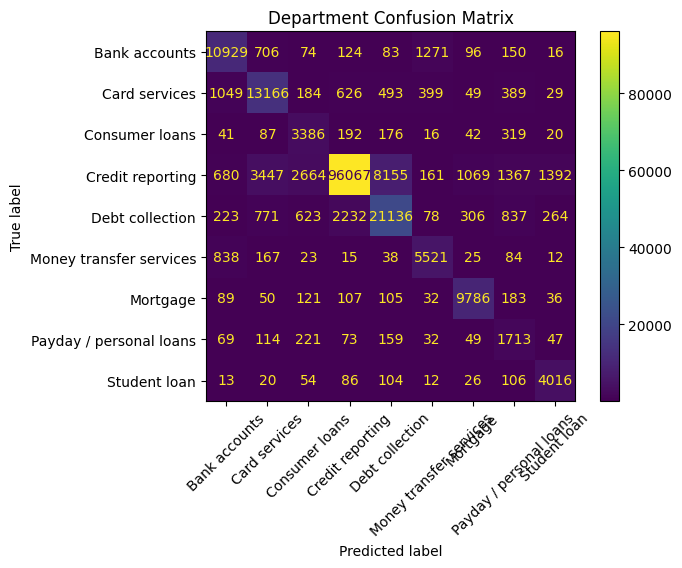

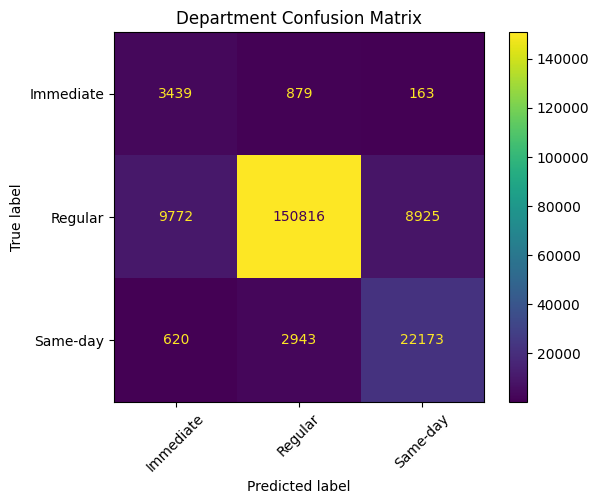

In [107]:
# Departmental model
ConfusionMatrixDisplay.from_predictions(
    y_test_dept,
    dept_preds_LR,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

#Priority Model
ConfusionMatrixDisplay.from_predictions(
    y_test_priority,
    priority_preds_LR,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

In [108]:
import joblib

# save priority model
joblib.dump(priority_pipeline__LR, "../models/priority_model.joblib")

# save department model
joblib.dump(dept_pipeline__LR, "../models/department_model.joblib")

['../models/department_model.joblib']